# Exploratory Data Analysis

In [1]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import os
import wfdb

In [2]:
DATA_DIR = '../data/mitdb'

## Class Distributions

This dataset uses 15 very specific medical heartbeat annotations, but standard practice (AAMI EC57 standard) is to map them into 5 superclasses:

- N (normal)
- S (supraventricular ectopic)
- V (ventricular ectopic)
- F (fusion)
- Q (unknown/paced)

Apply this grouping (per [source](https://arxiv.org/pdf/1810.04121)) to check the counts for each class

In [3]:
CLASS_TO_SYMBOLS = {
    'N': ['N', 'L', 'R', 'e', 'j'],
    'S': ['A', 'a', 'J', 'S'],
    'V': ['V', 'E'],
    'F': ['F'],
    'Q': ['/', 'f', 'Q'],
}

# create the inverse mapping to easily apply to the raw data
SYMBOL_TO_CLASS = {}

for class_name, symbols in CLASS_TO_SYMBOLS.items():
    for symbol in symbols:
        SYMBOL_TO_CLASS[symbol] = class_name

In [6]:
# Get record names, to read the corresponding annotation files below
records = [fl.split('.')[0] for fl in os.listdir(DATA_DIR) if fl.endswith('.hea')]
overall_counts = Counter()
per_record_counts = {}

for rec in sorted(records):
    ann = wfdb.rdann(f'{DATA_DIR}/{rec}', 'atr')
    mapped = [SYMBOL_TO_CLASS.get(symbol, 'other') for symbol in ann.symbol]
    counts = Counter(mapped)  # class counts for this record
    per_record_counts[rec] = counts
    overall_counts.update(counts)  # add to the running counts

print(overall_counts)

Counter({'N': 90631, 'Q': 8043, 'V': 7236, 'other': 3153, 'S': 2781, 'F': 803})


In [12]:
# What are the "other" symbols that couldn't map to one of the 5 classes?
other_symbols = Counter()

for rec in sorted(records):
    ann = wfdb.rdann(f'{DATA_DIR}/{rec}', 'atr')
    for symbol in ann.symbol:
        if symbol not in CLASS_TO_SYMBOLS:
            other_symbols[symbol] += 1
print(other_symbols)

Counter({'L': 8075, 'R': 7259, '/': 7028, 'A': 2546, '+': 1291, 'f': 982, '~': 616, '!': 472, '"': 437, 'j': 229, 'x': 193, 'a': 150, '|': 132, 'E': 106, 'J': 83, 'e': 16, '[': 6, ']': 6})


Notes

- Large imbalance with `N` (aka "Normal") heartbeats by far most common (over 10x more than the 2nd most frequent class)
- "Other" symbols look like markers for something other than the heartbeat itself. We can filter them out prior to labeling, given that we have a source of all expected symbols for heartbeat types

## Plot a couple signals

Notes

- I had assumed peaks would be in the positive direction, but sometimes they seem to be in the opposite direction
- There isn't any clear indicator in the record metadata to say which direction peaks will be; so the ETL process will need to account for this


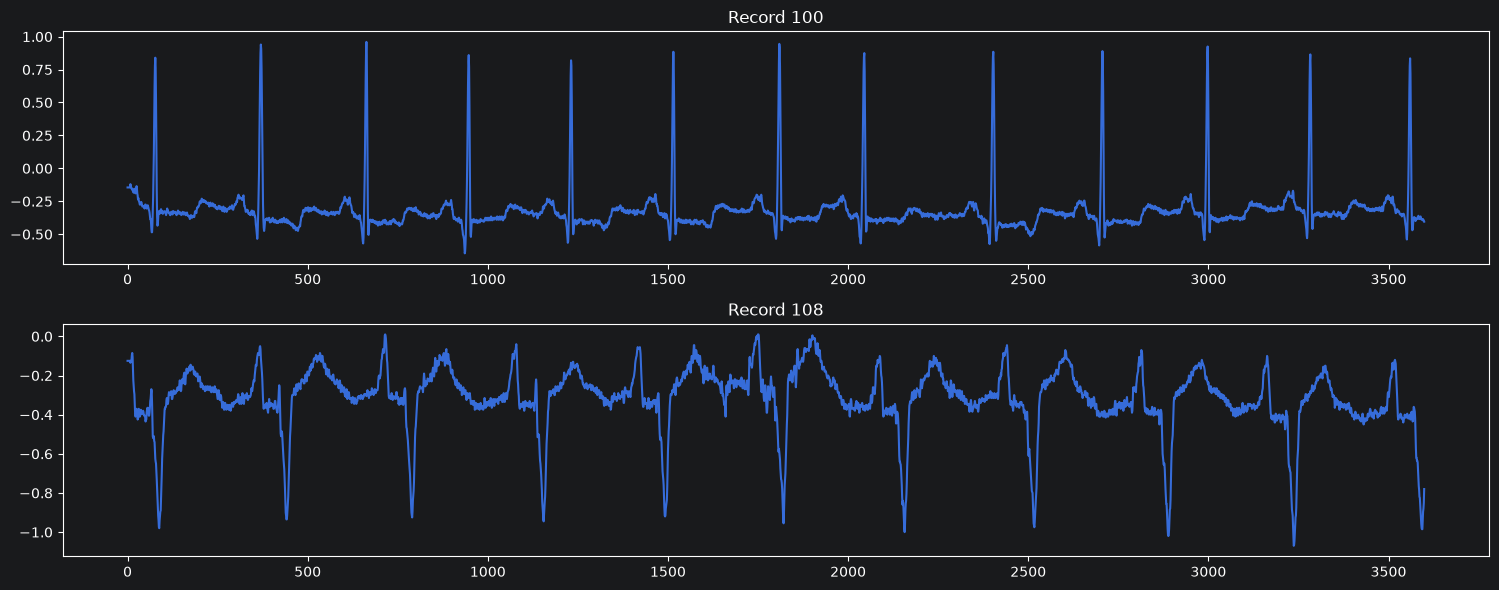

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6))
for ax, rec in zip(axes, ['100', '108']):  # 100 = cleaner, 108 = known noisier
    record = wfdb.rdrecord(f'{DATA_DIR}/{rec}')
    ax.plot(record.p_signal[:3600, 0])  # first 10 sec, lead 0
    ax.set_title(f'Record {rec}')

plt.tight_layout()
plt.show()

### Polarity Variation

More in depth look at polarity across records

Notes:

- Most peaks are in the positive direction; and only V1 type leads have majority negative polarity
- However several records have a median close to zero, so are not definitively positive or negative
- Since simple peak-detection methods assume positive polarity and will fail on inverted signals, we will need some strategy to handle negative polarity. Options:
    1. **Exclude affected records** - simplest, but we lose some data
    1. **Detect and correct programmatically** (check signal sign at annotated beat
  locations, and flip records that are consistently negative) - more robust but complex/error prone

In [24]:
# Estimate each lead's QRS polarity from annotated beat amplitudes
# Positive/negative means the signal value at the annotated beat relative to a short pre-beat baseline
polarity_by_record_lead = {}

for record_name in sorted(records):
    header = wfdb.rdheader(f'{DATA_DIR}/{record_name}')
    ecg_record = wfdb.rdrecord(f'{DATA_DIR}/{record_name}')
    annotations = wfdb.rdann(f'{DATA_DIR}/{record_name}', 'atr')
    # Keep beat locations; omit rhythm and signal-quality markers
    beat_positions = [sample_index for sample_index, symbol in zip(annotations.sample, annotations.symbol)
                      if symbol in SYMBOL_TO_CLASS]

    for channel_index, lead_name in enumerate(header.sig_name):
        signed_amplitudes = []
        for beat_position in beat_positions:
            # Use the 200–100 ms before the beat as a local baseline
            baseline_start = max(0, beat_position - int(0.2 * ecg_record.fs))
            baseline_end = max(0, beat_position - int(0.1 * ecg_record.fs))
            if baseline_end > baseline_start:
                baseline = np.median(ecg_record.p_signal[baseline_start:baseline_end, channel_index])
                # Positive means the annotated sample is above that baseline
                beat_amplitude = ecg_record.p_signal[beat_position, channel_index] - baseline
                signed_amplitudes.append(beat_amplitude)

        if signed_amplitudes:
            # Median gives one robust polarity estimate for this record and lead
            polarity_by_record_lead[(record_name, lead_name)] = np.median(signed_amplitudes)

for (record_name, lead_name), median_amplitude in sorted(polarity_by_record_lead.items()):
    direction = 'positive' if median_amplitude >= 0 else 'negative'
    print(f'{record_name} {lead_name}: median signed QRS amplitude {median_amplitude:.3f} ({direction})')

# Compare record-level signs for records with the same lead name
print('Positive-polarity fraction by lead name:')
for lead_name in sorted({lead_name for _, lead_name in polarity_by_record_lead}):
    lead_medians = [value for (record_name, current_lead), value in polarity_by_record_lead.items()
                    if current_lead == lead_name]
    positive_fraction = np.mean(np.array(lead_medians) > 0)
    print(f'{lead_name}: {positive_fraction:.1%} of records have positive median QRS amplitude')

100 MLII: median signed QRS amplitude 1.185 (positive)
100 V5: median signed QRS amplitude 0.525 (positive)
101 MLII: median signed QRS amplitude 1.607 (positive)
101 V1: median signed QRS amplitude -0.065 (negative)
102 V2: median signed QRS amplitude 0.330 (positive)
102 V5: median signed QRS amplitude 1.040 (positive)
103 MLII: median signed QRS amplitude 2.010 (positive)
103 V2: median signed QRS amplitude 1.232 (positive)
104 V2: median signed QRS amplitude 0.660 (positive)
104 V5: median signed QRS amplitude 0.647 (positive)
105 MLII: median signed QRS amplitude 1.383 (positive)
105 V1: median signed QRS amplitude -0.315 (negative)
106 MLII: median signed QRS amplitude 1.775 (positive)
106 V1: median signed QRS amplitude 0.060 (positive)
107 MLII: median signed QRS amplitude 2.090 (positive)
107 V1: median signed QRS amplitude -0.240 (negative)
108 MLII: median signed QRS amplitude 0.265 (positive)
108 V1: median signed QRS amplitude -0.720 (negative)
109 MLII: median signed QRS 

## Lead channels

- MLII = bipolar limb lead, "V leads" = unipolar chest leads
- MLII most common, usually but not always at index 0 --> ETL pipeline should look up channels by name, not by index
- **Decision:** What lead(s) data to use? Options:
     1. Use only MLII. Simpler, but also requires dropping some data
     2. Incorporate all lead data. Resulting model will likely be more robust, but requires more complex data processing

I think I will start with (1) and assess model accuracy; then maybe build a challenger model via (2)

In [25]:
lead_combos = Counter()

for rec in records:
    r = wfdb.rdheader(f'{DATA_DIR}/{rec}')
    lead_combos[tuple(r.sig_name)] += 1

print(lead_combos)

Counter({('MLII', 'V1'): 40, ('MLII', 'V5'): 2, ('V5', 'V2'): 2, ('MLII', 'V2'): 2, ('MLII', 'V4'): 1, ('V5', 'MLII'): 1})


## RR intervals / beat spacing

Per Cleveland Clinic: "A normal resting heart rate for most adults is 60 to 100 beats per minute"
which is ~= 0.6 to 1 second intervals

- Median is in the middle of this normal range, which makes sense
- The 5th and 90th seem reasonable too
- End of the range min/max anomalies could be annotation issues

In [18]:
VALID_BEAT_SYMBOLS = set(SYMBOL_TO_CLASS.keys())

all_rr = []
per_record_min = {}
per_record_max = {}

for rec in sorted(records):
    ann = wfdb.rdann(f'{DATA_DIR}/{rec}', 'atr')
    record = wfdb.rdrecord(f'{DATA_DIR}/{rec}')

    # only compute RR from actual beat annotations, not rhythm/quality markers
    beat_samples = [s for s, sym in zip(ann.sample, ann.symbol) if sym in VALID_BEAT_SYMBOLS]
    rr = np.diff(beat_samples) / record.fs

    all_rr.extend(rr)
    per_record_min[rec] = rr.min() if len(rr) else None
    per_record_max[rec] = rr.max() if len(rr) else None

all_rr = np.array(all_rr)
print(f"Median RR interval: {np.median(all_rr):.3f}s")
print(f"5th/95th percentile: {np.percentile(all_rr, 5):.3f}s / {np.percentile(all_rr, 95):.3f}s")
print(f"Min/Max: {all_rr.min():.3f}s / {all_rr.max():.3f}s")

# show which records have the most extreme RR intervals
shortest = sorted(
    ((rec, value) for rec, value in per_record_max.items() if value is not None),
    key=lambda x: x[1]
)[:5]
print("Shortest RR interval per record (lowest 5):", shortest)

longest = sorted(
    ((rec, value) for rec, value in per_record_max.items() if value is not None),
    key=lambda x: x[1],
    reverse=True,
)[:5]

print("Longest RR interval per record (highest 5):", longest)

Median RR interval: 0.764s
5th/95th percentile: 0.497s / 1.172s
Min/Max: 0.250s / 100.022s
Shortest RR interval per record (lowest 5): [('209', np.float64(0.8611111111111112)), ('213', np.float64(0.8972222222222223)), ('122', np.float64(0.9138888888888889)), ('109', np.float64(0.9194444444444444)), ('104', np.float64(0.9388888888888889))]
Longest RR interval per record (highest 5): [('207', np.float64(100.02222222222223)), ('232', np.float64(5.872222222222222)), ('201', np.float64(3.772222222222222)), ('208', np.float64(3.1277777777777778)), ('219', np.float64(3.077777777777778))]


Longest gap: 100.022s, from 1540.492s to 1640.514s


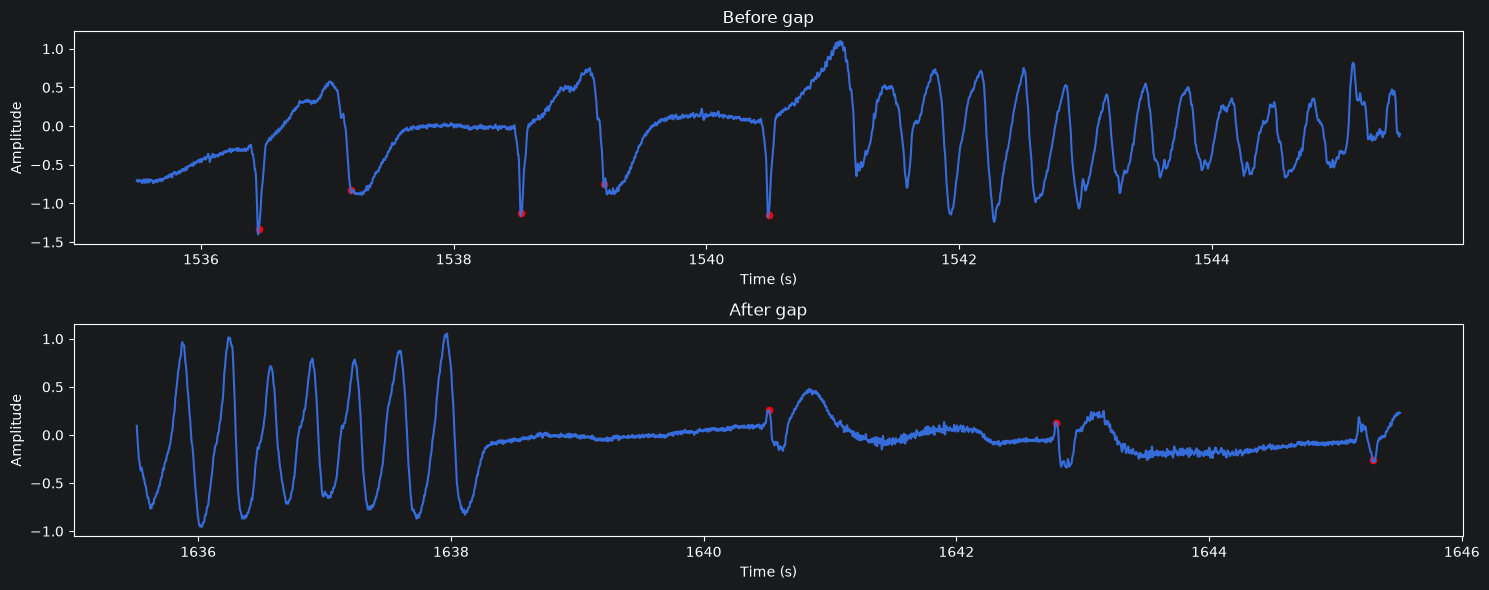

In [21]:
# Inspect the longest gap in record 207
rec = '207'
record = wfdb.rdrecord(f'{DATA_DIR}/{rec}')
ann = wfdb.rdann(f'{DATA_DIR}/{rec}', 'atr')
beat_samples = np.array([sample_index for sample_index, symbol in zip(ann.sample, ann.symbol)
                         if symbol in VALID_BEAT_SYMBOLS])

rr = np.diff(beat_samples) / record.fs
longest_interval_index = rr.argmax()
gap_start, gap_end = beat_samples[longest_interval_index], beat_samples[longest_interval_index + 1]
print(f'Longest gap: {rr[longest_interval_index]:.3f}s, from {gap_start / record.fs:.3f}s to {gap_end / record.fs:.3f}s')

# Plot 5 seconds around each end of the gap
fig, axes = plt.subplots(2, 1, figsize=(15, 6))
for axis, center, title in zip(axes, [gap_start, gap_end], ['Before gap', 'After gap']):
    window_start = max(0, center - int(5 * record.fs))
    window_end = min(record.sig_len, center + int(5 * record.fs))

    sample_indices = np.arange(window_start, window_end)
    axis.plot(sample_indices / record.fs, record.p_signal[window_start:window_end, 0])
    local_beats = beat_samples[(beat_samples >= window_start) & (beat_samples < window_end)]

    axis.scatter(local_beats / record.fs, record.p_signal[local_beats, 0], color='red', s=20)
    axis.set(title=title, xlabel='Time (s)', ylabel='Amplitude')

plt.tight_layout()

In [22]:
# Appears to be lots of ventricular flutter ("!")

in_gap = (ann.sample >= gap_start) & (ann.sample <= gap_end)
print(list(zip(ann.sample[in_gap] / record.fs, np.array(ann.symbol)[in_gap])))

[(np.float64(1540.4916666666666), np.str_('L')), (np.float64(1540.7833333333333), np.str_('[')), (np.float64(1540.9444444444443), np.str_('+')), (np.float64(1541.1833333333334), np.str_('!')), (np.float64(1541.5805555555555), np.str_('!')), (np.float64(1541.95), np.str_('!')), (np.float64(1542.2944444444445), np.str_('!')), (np.float64(1542.6083333333333), np.str_('!')), (np.float64(1542.9444444444443), np.str_('!')), (np.float64(1543.2583333333334), np.str_('!')), (np.float64(1543.6333333333334), np.str_('!')), (np.float64(1543.9), np.str_('!')), (np.float64(1544.3), np.str_('!')), (np.float64(1544.575), np.str_('!')), (np.float64(1544.8972222222221), np.str_('!')), (np.float64(1545.1305555555555), np.str_('!')), (np.float64(1545.4472222222223), np.str_('!')), (np.float64(1545.7833333333333), np.str_('!')), (np.float64(1546.1027777777779), np.str_('!')), (np.float64(1546.3972222222221), np.str_('!')), (np.float64(1546.7333333333333), np.str_('!')), (np.float64(1547.0472222222222), np.

In [ ]:
# TODO: can we abstract away/simplify repeated code in this notebook to make it easier to read, and extend with further analysis?